<a href="https://colab.research.google.com/github/Alchwalch/Deep-Learning-Study/blob/main/NLP/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Dataset,Subset,DataLoader,random_split
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
import itertools

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

# Layer

In [ ]:
class SelfAttention(nn.Module):
  def __init__(self, d_model, heads, dropout=0.0,qkv_bias=False):
    super(SelfAttention, self).__init__()
    assert (d_model % heads == 0), "d_model must be divisible by heads"

    self.d_model = d_model
    self.heads = heads
    self.head_dim = d_model // heads

    self.query= nn.Linear(d_model,d_model,bias=qkv_bias)
    self.key= nn.Linear(d_model,d_model,bias=qkv_bias)
    self.value= nn.Linear(d_model,d_model,bias=qkv_bias)
    self.out_fc=nn.Linear(d_model,d_model)
    self.dropout=nn.Dropout(dropout)


  def forward(self, q, k, v, mask=None):
    batch_size=q.shape[0]
    q_len,k_len,v_len=q.shape[1],k.shape[1],v.shape[1]

    q = self.query(q)
    k = self.key(k)
    v = self.value(v)

    q=q.view(batch_size,q_len,self.heads,self.head_dim)
    k=k.view(batch_size,k_len,self.heads,self.head_dim)
    v=v.view(batch_size,v_len,self.heads,self.head_dim)

    energy=torch.einsum("nqhd,nkhd->nhqk",[q,k])

    if mask is not None:
      energy=energy.masked_fill(mask==0,-torch.inf)

    attention=torch.softmax(energy/(self.head_dim**(1/2)),dim=-1)
    attention=self.dropout(attention)

    out=torch.einsum("nhql,nlhd->nqhd",[attention,v])
    out=out.reshape(batch_size,q_len,self.d_model)

    return self.out_fc(out)

In [ ]:
class FeedForward(nn.Module):
  def __init__(self,d_model):
    super(FeedForward,self).__init__()
    self.layers=nn.Sequential(
        nn.Linear(d_model,d_model*4),
        nn.ReLU(),
        nn.Linear(d_model*4,d_model)
    )

  def forward(self,x):
    return self.layers(x)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super(PositionalEncoding, self).__init__()
        self.register_buffer("pe", self._get_pe(d_model, max_len))

    def _get_pe(self, d_model, max_len):
        pe = torch.zeros(max_len, d_model)
        pe.requires_grad = False

        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )  # (d_model/2,)

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        return pe

    def forward(self, x):
        x = x + self.pe[:x.shape[1]]
        return x

In [ ]:
class EncoderBlock(nn.Module):
  def __init__(self,cfg):
    super(EncoderBlock,self).__init__()
    self.attention=SelfAttention(cfg["d_model"],cfg["n_heads"],cfg["drop_attn"])
    self.norm1=nn.LayerNorm(cfg["d_model"])
    self.drop1=nn.Dropout(cfg["drop_res"])

    self.feed_forward=FeedForward(cfg["d_model"])
    self.norm2=nn.LayerNorm(cfg["d_model"])
    self.drop2=nn.Dropout(cfg["drop_res"])

  def forward(self,x,mask=None):
    shortcut=x
    x=self.attention(x,x,x,mask)
    x=self.drop1(x)
    x=self.norm1(x+shortcut)

    shortcut=x
    x=self.feed_forward(x)
    x=self.drop2(x)
    x=self.norm2(x+shortcut)

    return x

In [ ]:
class Encoder(nn.Module):
  def __init__(self,cfg):
    super(Encoder,self).__init__()
    self.word_embedding=nn.Embedding(cfg["vocab_size"],cfg["d_model"])
    self.pos_embedding=PositionalEncoding(cfg["d_model"],cfg["max_len"])
    self.drop=nn.Dropout(cfg["drop_emb"])
    self.layers=nn.ModuleList([EncoderBlock(cfg) for _ in range(cfg["n_layers"])])

  def forward(self,idx,mask=None):
    x=self.word_embedding(idx)
    x=self.pos_embedding(x)
    x=self.drop(x)

    for layer in self.layers:
      x=layer(x,mask)

    return x

In [ ]:
class DecoderBlock(nn.Module):
  def __init__(self,cfg):
    super(DecoderBlock,self).__init__()
    self.masked_attention=SelfAttention(cfg["d_model"],cfg["n_heads"],cfg["drop_attn"])
    self.norm1=nn.LayerNorm(cfg["d_model"])
    self.drop1=nn.Dropout(cfg["drop_res"])

    self.attention=SelfAttention(cfg["d_model"],cfg["n_heads"],cfg["drop_attn"])
    self.norm2=nn.LayerNorm(cfg["d_model"])
    self.drop2=nn.Dropout(cfg["drop_res"])

    self.feed_forward=FeedForward(cfg["d_model"])
    self.norm3=nn.LayerNorm(cfg["d_model"])
    self.drop3=nn.Dropout(cfg["drop_res"])

  def forward(self,x,encoder_out,trg_mask,src_mask=None):
    shortcut=x
    x=self.masked_attention(x,x,x,trg_mask)
    x=self.drop1(x)
    x=self.norm1(x+shortcut)

    shortcut=x
    x=self.attention(x,encoder_out,encoder_out,src_mask)
    x=self.drop2(x)
    x=self.norm2(x+shortcut)

    shortcut=x
    x=self.feed_forward(x)
    x=self.drop3(x)
    x=self.norm3(x+shortcut)

    return x

In [ ]:
class Decoder(nn.Module):
  def __init__(self,cfg):
    super(Decoder,self).__init__()
    self.word_embedding=nn.Embedding(cfg["vocab_size"],cfg["d_model"])
    self.pos_embedding=PositionalEncoding(cfg["d_model"],cfg["max_len"])
    self.drop=nn.Dropout(cfg["drop_emb"])
    self.layers=nn.ModuleList([DecoderBlock(cfg) for _ in range(cfg["n_layers"])])
    self.fc=nn.Linear(cfg["d_model"],cfg["vocab_size"])
    self.softmax=nn.Softmax(dim=-1)

  def forward(self,idx,encoder_out,trg_mask,src_mask=None):
    x=self.word_embedding(idx)
    x=self.pos_embedding(x)
    x=self.drop(x)

    for layer in self.layers:
      x=layer(x,encoder_out,trg_mask,src_mask)

    x=self.fc(x)

    return x

In [ ]:
class Transformer(nn.Module):
  def __init__(self,cfg):
    super(Transformer,self).__init__()
    self.encoder=Encoder(cfg)
    self.decoder=Decoder(cfg)
    self.device=cfg["device"]
    self.pad_idx = cfg["pad_idx"]

  def make_src_mask(self,src):
    #query쪽은 신경 ㄴㄴ Key 쪽에서만 padding 처리
    batch_size,seq_len=src.shape
    mask = (src != self.pad_idx).unsqueeze(1).unsqueeze(2)
    return mask.to(self.device)

  def make_trg_mask(self,trg):
    batch_size, seq_len = trg.shape
    pad_mask = (trg != self.pad_idx).unsqueeze(1).unsqueeze(2)
    causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=self.device)).bool()
    causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)
    return (pad_mask & causal_mask).to(self.device)

  def forward(self,src,trg):
    src_mask=self.make_src_mask(src)
    trg_mask=self.make_trg_mask(trg)
    encoder_out=self.encoder(src,src_mask)
    out=self.decoder(trg,encoder_out,trg_mask,src_mask)

    return out


In [ ]:
def calc_loss_batch(input_batch,target_batch,model,device,label_smoothing=0.0):
  input_batch=input_batch.to(device)
  target_batch=target_batch.to(device)

  tgt_input=target_batch[:,:-1]
  tgt_output=target_batch[:,1:]
  out=model(input_batch,tgt_input)

  loss=F.cross_entropy(out.reshape(-1,out.shape[-1]),tgt_output.reshape(-1),ignore_index=PAD_ID, label_smoothing=label_smoothing)

  return loss

5 에포크 부터 label_smoothing 추가

In [ ]:
def calc_loss_loader(data_loader,model,device,num_batches=None):
  total_loss=0
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches=len(data_loader)
  else:
    num_batches=min(num_batches,len(data_loader))

  for i,(src,trg) in enumerate(data_loader):
    if i >= num_batches:
      break

    loss=calc_loss_batch(src,trg,model,device)
    total_loss+=loss.item()

  return total_loss/num_batches

# Setting

In [ ]:
epochs=10
learning_rate=1.0
batch_size=64
early_stop_patience = 10
max_length=128

In [ ]:
#%%script echo skip

from datasets import load_dataset

print("loading...")
dataset = load_dataset("regisss/wmt14-en-de-pre-processed")
print(dataset)

In [ ]:
train_dataset=dataset["train"].shuffle(seed=67).select(range(1_920_000))
val_dataset=dataset["validation"]
test_dataset=dataset["test"]

with open("en_de_combined.txt", "w", encoding="utf-8") as f:
    for item in train_dataset:   # train만
        pair = item["translation"]
        f.write(pair["en"].strip() + "\n")
        f.write(pair["de"].strip() + "\n")

In [ ]:
import sentencepiece as spm

spm.SentencePieceTrainer.train(
    input="en_de_combined.txt",
    model_prefix="wmt14_bpe",
    vocab_size=32000,
    model_type="bpe",
    character_coverage=1.0,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
)

sp = spm.SentencePieceProcessor()
sp.load("wmt14_bpe.model")

PAD_ID = sp.pad_id()
UNK_ID = sp.unk_id()
BOS_ID = sp.bos_id()
EOS_ID = sp.eos_id()
VOCAB_SIZE = sp.get_piece_size()

model_prefix: 결과물 파일 이름의 접두사. 학습이 끝나면 wmt14_bpe.model(토크나이저 본체)과 wmt14_bpe.vocab(vocab 목록, 사람이 읽을 수 있는 텍스트)이 생성됨

vocab_size=32000: 최종 vocab 크기. BPE는 문자 단위에서 시작해서 빈도 높은 쌍을 반복적으로 병합하는데, 이 병합을 몇 번 할지를 사실상 이 숫자가 결정함

model_type="bpe": SentencePiece는 BPE 말고 "unigram" 방식도 지원하는데, 논문 재현이 목적이면 "bpe"가 맞음

character_coverage=1.0: 학습 코퍼스에 등장하는 문자를 몇 %까지 vocab에 포함시킬지. 기본값은 0.9995라서 아주 드문 문자(독일어 움라우트 ä/ö/ü, ß 같은)가 빠질 수 있음 — 그래서 1.0으로 명시

In [ ]:
class SPTokenizerWrapper:
    def __init__(self, sp):
        self.sp = sp
    def encode(self, text):
        return self.sp.encode(text, out_type=int)
    def decode(self, ids):
        return self.sp.decode(ids)

tokenizer = SPTokenizerWrapper(sp)

In [ ]:
'''import tiktoken
tokenizer=tiktoken.get_encoding("gpt2")

BOS_ID = tokenizer.n_vocab
EOS_ID = tokenizer.n_vocab+1
PAD_ID = tokenizer.n_vocab+2'''

In [ ]:
'''def text_to_token_ids(text,tokenizer):
  encoded=tokenizer.encode(text,allowed_special={"<|endoftext|>"})
  encoded_tensor=torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(token_ids,tokenizer):
  flat = token_ids.squeeze(0).tolist()
  # BOS/EOS/PAD처럼 gpt2 vocab 범위를 벗어난 커스텀 id는 디코딩 전에 제거
  filtered = [t for t in flat if t < tokenizer.n_vocab]
  return tokenizer.decode(filtered)'''

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_length):
        self.max_length = max_length
        self.pairs = []
        for item in dataset:
            item = item["translation"]
            src = tokenizer.encode(item["en"])[: max_length - 2]
            tgt = tokenizer.encode(item["de"])[: max_length - 2]
            self.pairs.append((
                torch.tensor([BOS_ID] + src + [EOS_ID]),
                torch.tensor([BOS_ID] + tgt + [EOS_ID]),
            ))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]

In [ ]:
'''
class TranslationDataset(Dataset):
  def __init__(self,dataset,tokenizer,max_length):
    self.dataset=dataset
    self.tokenizer=tokenizer
    self.max_length=max_length

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self,idx):
    item = self.dataset[idx]["translation"]

    src_text = item["en"]
    tgt_text = item["de"]

    src = self.tokenizer.encode(src_text)[: self.max_length - 2]
    tgt = self.tokenizer.encode(tgt_text)[: self.max_length - 2]

    src = [BOS_ID] + src + [EOS_ID]
    tgt = [BOS_ID] + tgt + [EOS_ID]

    return torch.tensor(src), torch.tensor(tgt)
        '''

속도 향상: getitem에서 있는 tokenizer.encode()함수를 바깥으로 빼 놓음

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
  src_batch, tgt_batch = zip(*batch)

  src_batch = pad_sequence(
      src_batch,
      batch_first=True,
      padding_value=PAD_ID
  )

  tgt_batch = pad_sequence(
      tgt_batch,
      batch_first=True,
      padding_value=PAD_ID
  )

  return src_batch, tgt_batch

In [ ]:
def create_dataloader(dataset, tokenizer, batch_size, max_length,shuffle=True,drop_last=True,collate_fn=None,num_workers=2):
  dataset=TranslationDataset(dataset,tokenizer,max_length)
  dataloader=DataLoader(
      dataset,
      batch_size=batch_size,
      shuffle=shuffle,
      drop_last=drop_last,
      collate_fn=collate_fn,
      num_workers=num_workers
  )

  return dataloader

세컨드

16만 train dataset에서 1000000 으로

In [ ]:
train_loader=create_dataloader(
    train_dataset,
    tokenizer,
    batch_size,
    max_length,
    shuffle=True,
    drop_last=True,
    collate_fn=collate_fn,
    num_workers=0
)

val_loader=create_dataloader(
    val_dataset,
    tokenizer,
    batch_size,
    max_length,
    shuffle=False,
    drop_last=True,
    collate_fn=collate_fn,
    num_workers=0
)

test_loader=create_dataloader(
    test_dataset,
    tokenizer,
    batch_size,
    max_length,
    shuffle=False,
    drop_last=True,
    collate_fn=collate_fn,
    num_workers=0
)

# Training

In [ ]:
TRANSFORMER_BASE_CONFIG={
    "vocab_size":VOCAB_SIZE,
    "max_len":1024,
    "d_model":512,
    "n_heads":8,
    "n_layers":6,
    "drop_attn":0.1,
    "drop_res":0.1,
    "drop_emb":0.1,
    "pad_idx":PAD_ID,
    "qkv_bias": False,
    "device": 'cuda' if torch.cuda.is_available() else 'cpu'
}

세컨 트라이

drop_attn 0.0 -> 0.1

drop_res 0.1 -> 0.2

drop_emb 0.1 -> 0.2

In [ ]:
from torch.optim.lr_scheduler import LambdaLR

def noam_lr_lambda(step_num, d_model, warmup_steps):
    # step_num=0에서 0**-0.5 = inf가 나오는 걸 방지
    step_num = max(step_num, 1)
    return (d_model ** -0.5) * min(step_num ** -0.5, step_num * (warmup_steps ** -1.5))

warmup_steps = 4000

model=Transformer(TRANSFORMER_BASE_CONFIG).to(TRANSFORMER_BASE_CONFIG["device"])
optimizer=optim.Adam(model.parameters(),lr=learning_rate, betas=(0.9, 0.98), eps=1e-9)
scheduler = LambdaLR(
    optimizer,
    lr_lambda=lambda step: noam_lr_lambda(step, TRANSFORMER_BASE_CONFIG["d_model"], warmup_steps)
)

device = TRANSFORMER_BASE_CONFIG["device"]
use_amp = (device == "cuda")

scaler = torch.amp.GradScaler(device, enabled=use_amp)

속도 향상: scaler 추가

In [ ]:
path = f'/content/drive/MyDrive/BLEU5.pth'

best_loss=float('inf')
no_improve=0
train_loss_list=[]
val_loss_list=[]

In [ ]:
def load_model(path, model, optimizer, scheduler, scaler, device):
    if not os.path.exists(path):
        print("체크포인트 없음, 처음부터 시작")
        return 0, float('inf'), [], [], 0  #  global_step, best_loss, train_list, val_list, no_improve

    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])

    global_step = checkpoint.get('global_step', 0)
    best_loss = checkpoint['best_loss']
    train_loss_list = checkpoint['train_loss_list']
    val_loss_list = checkpoint['val_loss_list']
    no_improve = checkpoint.get('no_improve', 0)

    print(f"불러오기 완료 (global_step={global_step})")
    return global_step, best_loss, train_loss_list, val_loss_list, no_improve

In [ ]:
def evaluate_model(model, data_loader, device,eval_iter):
    model.eval()
    with torch.no_grad(), torch.amp.autocast(device, enabled=use_amp):
        loss=calc_loss_loader(data_loader,model,device,eval_iter)
    model.train()
    return loss

In [ ]:
eval_interval = 1000
global_step = 0
running_train_loss = 0.0
running_count = 0
stop_training = False

In [ ]:
global_step, best_loss, train_loss_list, val_loss_list, no_improve = load_model(
    path, model, optimizer, scheduler, scaler, device
)

steps_per_epoch = len(train_loader)
resume_epoch = global_step // steps_per_epoch
batch_offset = global_step % steps_per_epoch

In [ ]:
for epoch in tqdm(range(resume_epoch, epochs), desc="Epoch",initial=resume_epoch, total=epochs):
    model.train()

    if epoch == resume_epoch and batch_offset > 0:
        loader = itertools.islice(train_loader, batch_offset, None)
        print(f"epoch {epoch}: {batch_offset} step 건너뛰고 재개")
    else:
        loader = train_loader

    for input_batch, target_batch in tqdm(loader, desc="Iteration", leave=False,initial=(batch_offset if epoch == resume_epoch else 0),total=steps_per_epoch):
        optimizer.zero_grad()

        with torch.amp.autocast(device, enabled=use_amp):
            loss = calc_loss_batch(input_batch, target_batch, model, device, label_smoothing=0.1)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_train_loss += loss.item()
        running_count += 1
        global_step += 1

        if global_step % eval_interval == 0:
            avg_train_loss = running_train_loss / running_count
            val_loss = evaluate_model(model, val_loader, device, None)

            train_loss_list.append((global_step, avg_train_loss))
            val_loss_list.append((global_step, val_loss))
            running_train_loss, running_count = 0.0, 0

            if val_loss < best_loss:
                best_loss = val_loss
                no_improve = 0
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'scaler_state_dict': scaler.state_dict(),
                    'train_loss_list': train_loss_list,
                    'val_loss_list': val_loss_list,
                    'global_step': global_step,
                    'best_loss': best_loss,
                    'no_improve': no_improve,
                }, path)
            else:
                no_improve += 1
                if no_improve >= early_stop_patience:
                    print(f"Early Stopping at step {global_step}")
                    stop_training = True
                    break

    if stop_training:
        break

In [ ]:
# %%script echo skip

'''
for epoch in tqdm(range(start_epoch, epochs), desc="Epoch"):

  train_loss=0.0
  val_loss=0.0
  model.train()

  for input_batch,target_batch in tqdm(train_loader, desc="Iteration", leave=False):

    optimizer.zero_grad()

    with torch.amp.autocast(device, enabled=use_amp):
      loss=calc_loss_batch(input_batch,target_batch,model,device)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()
    train_loss+=loss.item()


  train_loss/=len(train_loader)
  val_loss=evaluate_model(model,val_loader,device,None)

  train_loss_list.append(train_loss)
  val_loss_list.append(val_loss)

  if val_loss < best_loss:
        best_loss = val_loss
        no_improve = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss_list': train_loss_list,
            'val_loss_list': val_loss_list,
            'epoch': epoch,
            'best_loss': best_loss,
            'scaler_state_dict': scaler.state_dict()
        }, path)
  else:
      no_improve += 1
      if no_improve >= early_stop_patience:
          print(f"Early Stopping at Epoch {epoch+1}")
          break
          '''

# Showing

In [ ]:
train_steps, train_losses = zip(*train_loss_list)
val_steps, val_losses = zip(*val_loss_list)

plt.plot(train_steps, train_losses, label='Train Loss')
plt.plot(val_steps, val_losses, label='Validation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.show()

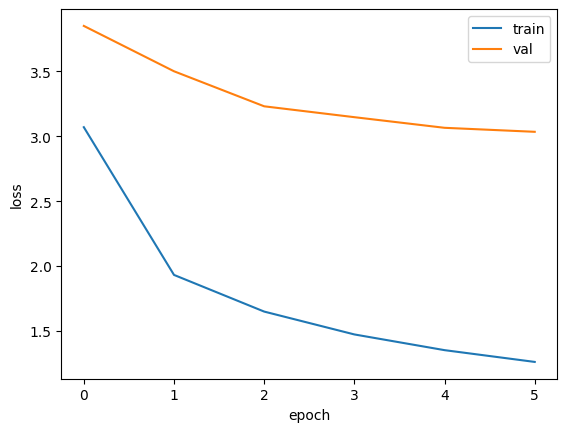

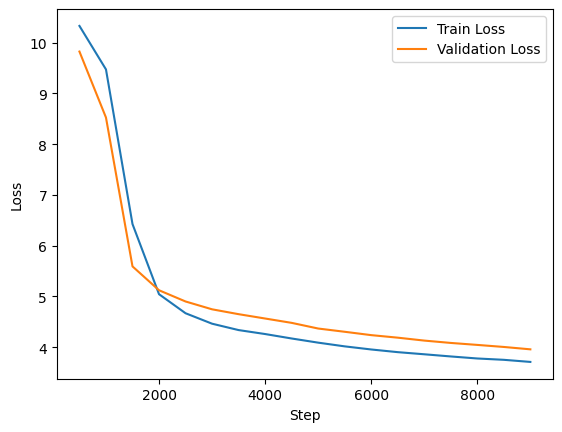

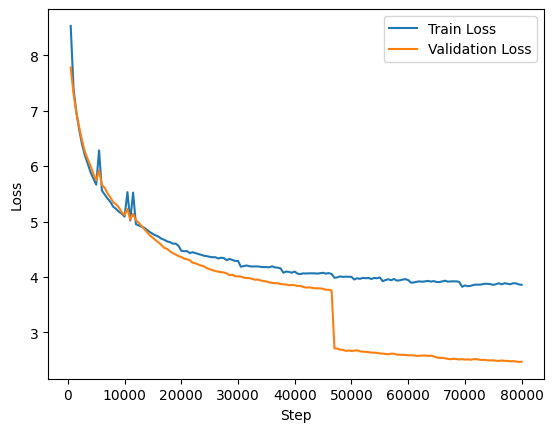

In [ ]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text)   # SPTokenizerWrapper.encode -> List[int]
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, sp):
    flat = token_ids.squeeze(0).tolist()
    # PAD/EOS 등 special id도 SentencePiece 자체가 알고 있으므로 필터링 불필요
    # decode_ids가 special token은 알아서 처리함
    return sp.decode(flat)

In [ ]:
@torch.no_grad()
def generate(model, src, max_new_token, max_length, temperature=0.0, top_k=None, device='cpu'):
    model.eval()
    src = src.to(device)
    src_mask = model.make_src_mask(src)
    with torch.amp.autocast(device, enabled=use_amp):
        encoder_out = model.encoder(src, src_mask)

    idx = torch.tensor([[BOS_ID]], device=device)
    for _ in range(max_new_token):
        idx_cond = idx[:, -max_length:]
        trg_mask = model.make_trg_mask(idx_cond)

        with torch.amp.autocast(device, enabled=use_amp):
            logits = model.decoder(idx_cond, encoder_out, trg_mask, src_mask)

        logits = logits[:, -1, :]

        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float("inf")

        if temperature > 0.0:
            logits = logits / temperature
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next.item() == EOS_ID:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [ ]:
test_loss = evaluate_model(model, test_loader, TRANSFORMER_BASE_CONFIG["device"], None)
print(f"Final test perplexity: {math.exp(test_loss):.4f}")

In [ ]:
print(optimizer.param_groups[0]['lr'])

In [ ]:
print("번역기 (영어 -> 독일어)")

prompt=input("영어 문장을 입력하세요: ")

token_ids=generate(
    model,
    text_to_token_ids(prompt,tokenizer),
    max_new_token=128,
    max_length=128,
    temperature=1.0,
    top_k=5,
    device=TRANSFORMER_BASE_CONFIG["device"]
)

print("출력 텍스트: ", token_ids_to_text(token_ids,tokenizer))

번역기 (영어 -> 독일어)

영어 문장을 입력하세요: I love you

출력 텍스트:  TUNz01bersch/legehei

번역기 (영어 -> 독일어)

영어 문장을 입력하세요: I love you

출력 텍스트:  Ich bin sehr gutes Wert, und wir habe Ihr gutes Wert gehabt, wenn es nicht gab.

gpt2 토큰 버전 (예상보다 좀 엄.. ㅇㅇ)

번역기 (영어 -> 독일어)

영어 문장을 입력하세요: I love you

출력 텍스트:  Das Das sehr Sie Sie! Hotel sehr Sie... Sie Du!... ... Du Du Du Sie......! Sie Du ...! Du......!! ...... ... Sie Sie...!! ... Sie!! Sie! ...............! Liebe Liebe!... ...!!!!... ......! Liebe Sie...... Liebe Liebe ......... ... ...!...... ......... Sie...!...! ...... ... Du Du ... Sie! Liebe ... ... Sie......... ... Du...! ......!...!! ... ... Du Sie Ihr...... Sie Sie Ihr!...!...... Sie!

**그냥 개 웃겨서 남김** 5000 step

번역기 (영어 -> 독일어)

영어 문장을 입력하세요: I hate you

출력 텍스트:  Die meisten dieser Themen sind in der Regel von der Entwicklung der einzelnen Länder.

**I로 시작하는 문장은 Ich가 아니라 Die meisten dieser Themen으로 시작하고 있음.**

번역기 (영어 -> 독일어)
영어 문장을 입력하세요: The committee will vote on the proposal next week.
출력 텍스트:  Der Ausschuß wird über die nächste Lesung abstimmen.

번역기 (영어 -> 독일어)
영어 문장을 입력하세요: Rising energy prices have affected millions of households.
출력 텍스트:  Die Preise für energiegeladene Energien sind von Bedeutung.

번역기 (영어 -> 독일어)
영어 문장을 입력하세요: The two countries agreed to strengthen trade relations.
출력 텍스트:  Die Beziehungen werden in den einzelnen Bereichen der Europäischen Union aufgenommen

**3번임**

정리

아키텍처 버그(cross-attention에 encoder_out 안 넘김, softmax 이중 적용 등) — 왜 틀렸는지 원리 설명

Padding mask를 query가 아니라 key 쪽에서만 처리해도 되는 이유 — attention 메커니즘에 대한 이해도를 보여주는 지점

42분 → 16분 최적화 과정에서 "AMP가 2.6배 개선을 냈다 = GPU가 병목이었다"는 추론 과정 (num_workers 늘려도 효과 없었던 것까지 포함)

Train/val loss curve를 보고 overfitting 시작 신호를 읽어낸 것, PPL 24가 왜 "아직 이른 단계"인지 원 논문 스텝 수와 비교해서 판단한 것

Dropout+label smoothing을 "동시에 바꾸면 원인 구분이 안 되니 처음부터 다시" 같은 실험 설계 판단

epoch 마다가 아니라 iteration 주기마다

토크나이저 변경 (속도 더 빨라짐) (에포크당 65분 -> 40분)